# **EDA e Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pyarrow
import warnings
warnings.filterwarnings('ignore')


# Rojo  → Charged Off (default=1)  |  Azul → Fully Paid (default=0)
CMAP        = 'RdYlBu'               # colormap continuo
C_PAID      = '#4393C3'              # azul  – Fully Paid
C_DEFAULT   = '#D6604D'              # rojo  – Charged Off
PALETTE_2   = [C_PAID, C_DEFAULT]    # [0, 1]
PALETTE_DIV = sns.color_palette(CMAP, n_colors=10)  # para categóricas

# Estilo global
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi'      : 130,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize'  : 12,
})

## **Carga y Preparacion de Datos**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df_acc = pd.read_csv(
    '/content/drive/MyDrive/Datasets/Miniproyecto 1/accepted_2007_to_2018Q4.csv',
    low_memory=False
)
print(f'Dataset cargado: {df_acc.shape[0]:,} filas × {df_acc.shape[1]} columnas')

Mounted at /content/drive
Dataset cargado: 2,260,701 filas × 151 columnas


In [3]:
df_acc.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Filtrado a estados finales y creación del target
df = df_acc[df_acc['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['default'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)

print(f'\nRegistros tras filtrado: {df.shape[0]:,}')


Registros tras filtrado: 1,345,310


In [5]:
# Selección de features
selected_features = [
    'loan_amnt',        # Monto del préstamo
    'int_rate',         # Tasa de interés
    'fico_range_high',  # Puntuación FICO (límite superior)
    'emp_length',       # Antigüedad laboral
    'annual_inc',       # Ingreso anual
    'purpose',          # Propósito del préstamo
    'home_ownership',   # Situación de la vivienda
    'dti',              # Ratio deuda-ingreso
    'addr_state',       # Estado de residencia
    'default'           # Variable objetivo
]

df_subset = df[selected_features].copy()

print('── Información general ──')
df_subset.info()

print('\n── Valores faltantes (%) ──')
miss = (df_subset.isnull().sum() / len(df_subset) * 100).sort_values(ascending=False)
print(miss[miss > 0].round(2).to_string())

── Información general ──
<class 'pandas.core.frame.DataFrame'>
Index: 1345310 entries, 0 to 2260697
Data columns (total 10 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   loan_amnt        1345310 non-null  float64
 1   int_rate         1345310 non-null  float64
 2   fico_range_high  1345310 non-null  float64
 3   emp_length       1266799 non-null  object 
 4   annual_inc       1345310 non-null  float64
 5   purpose          1345310 non-null  object 
 6   home_ownership   1345310 non-null  object 
 7   dti              1344936 non-null  float64
 8   addr_state       1345310 non-null  object 
 9   default          1345310 non-null  int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 112.9+ MB

── Valores faltantes (%) ──
emp_length    5.84
dti           0.03


## **Analisis Exploratorio de Datos**

## **Distribucion de la Variable Target**

          Clase  Conteo  Porcentaje
 Fully Paid (0) 1076751       80.04
Charged Off (1)  268559       19.96


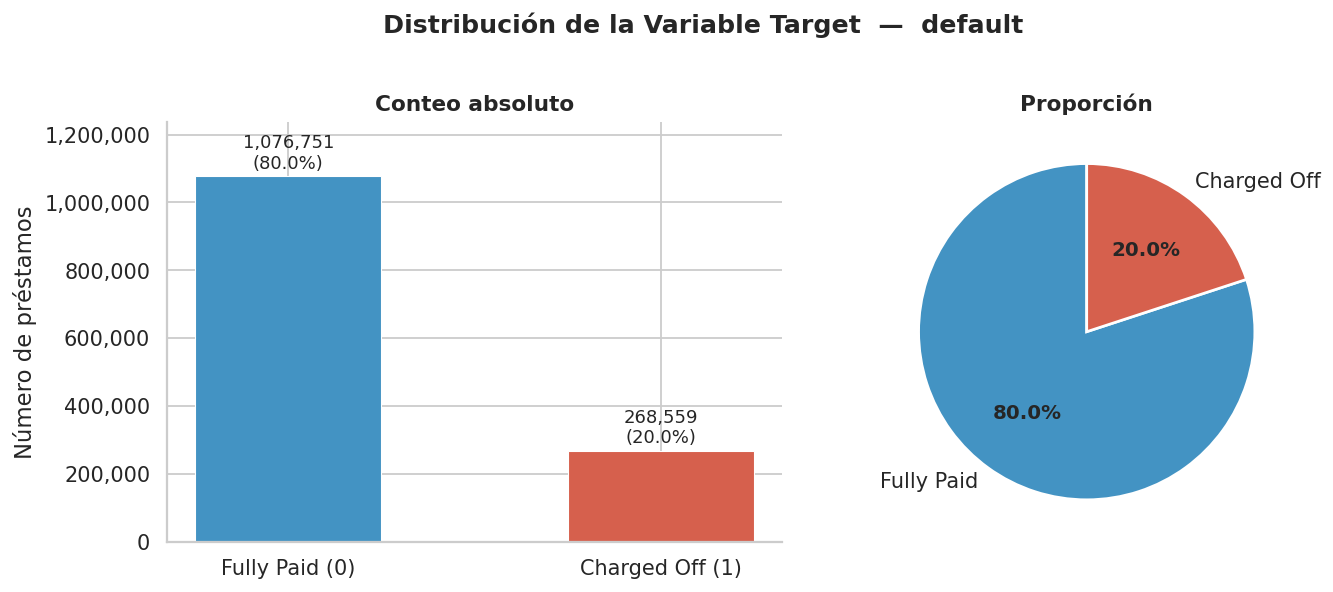

In [6]:
counts = df_subset['default'].value_counts().sort_index()
props  = counts / counts.sum() * 100

summary = pd.DataFrame({
    'Clase'     : ['Fully Paid (0)', 'Charged Off (1)'],
    'Conteo'    : counts.values,
    'Porcentaje': props.round(2).values
})
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Distribución de la Variable Target  —  default', fontsize=14, fontweight='bold', y=1.01)

# Barras
bars = axes[0].bar(['Fully Paid (0)', 'Charged Off (1)'], counts.values,
                   color=PALETTE_2, edgecolor='white', linewidth=0.6, width=0.5)
for bar, cnt, pct in zip(bars, counts.values, props.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.01,
                 f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Conteo absoluto')
axes[0].set_ylabel('Número de préstamos')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie
wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=['Fully Paid', 'Charged Off'],
    colors=PALETTE_2,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[1].set_title('Proporción')

plt.tight_layout()
plt.show()

Podemos apreciar un claro desbalanceo de clases. Esto supondra un problema para el modelo a la hora de predecir, y sera comun ver un grtan volumen de Falsos Negativos.

## **Estadisticas Descriptivas**

In [7]:
num_cols = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti']

desc = df_subset.groupby('default')[num_cols].describe().T
desc.columns = ['Fully Paid (0)', 'Charged Off (1)']

# Mostrar solo las estadísticas más relevantes
stats_to_show = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
print('── Estadísticas descriptivas por clase ──\n')
print(desc.loc[(slice(None), stats_to_show), :].round(2).to_string())

── Estadísticas descriptivas por clase ──

                      Fully Paid (0)  Charged Off (1)
loan_amnt       mean        14134.37         15565.06
                std          8669.03          8814.56
                min           500.00           900.00
                25%          7500.00          9000.00
                50%         12000.00         14350.00
                75%         20000.00         20400.00
                max         40000.00         40000.00
int_rate        mean           12.62            15.71
                std             4.53             4.91
                min             5.31             5.31
                25%             9.17            12.29
                50%            12.23            15.05
                75%            15.31            18.55
                max            30.99            30.99
fico_range_high mean          702.26           691.85
                std            32.83            25.95
                min           629.00   

## **Distribucion de Variables Numericas**

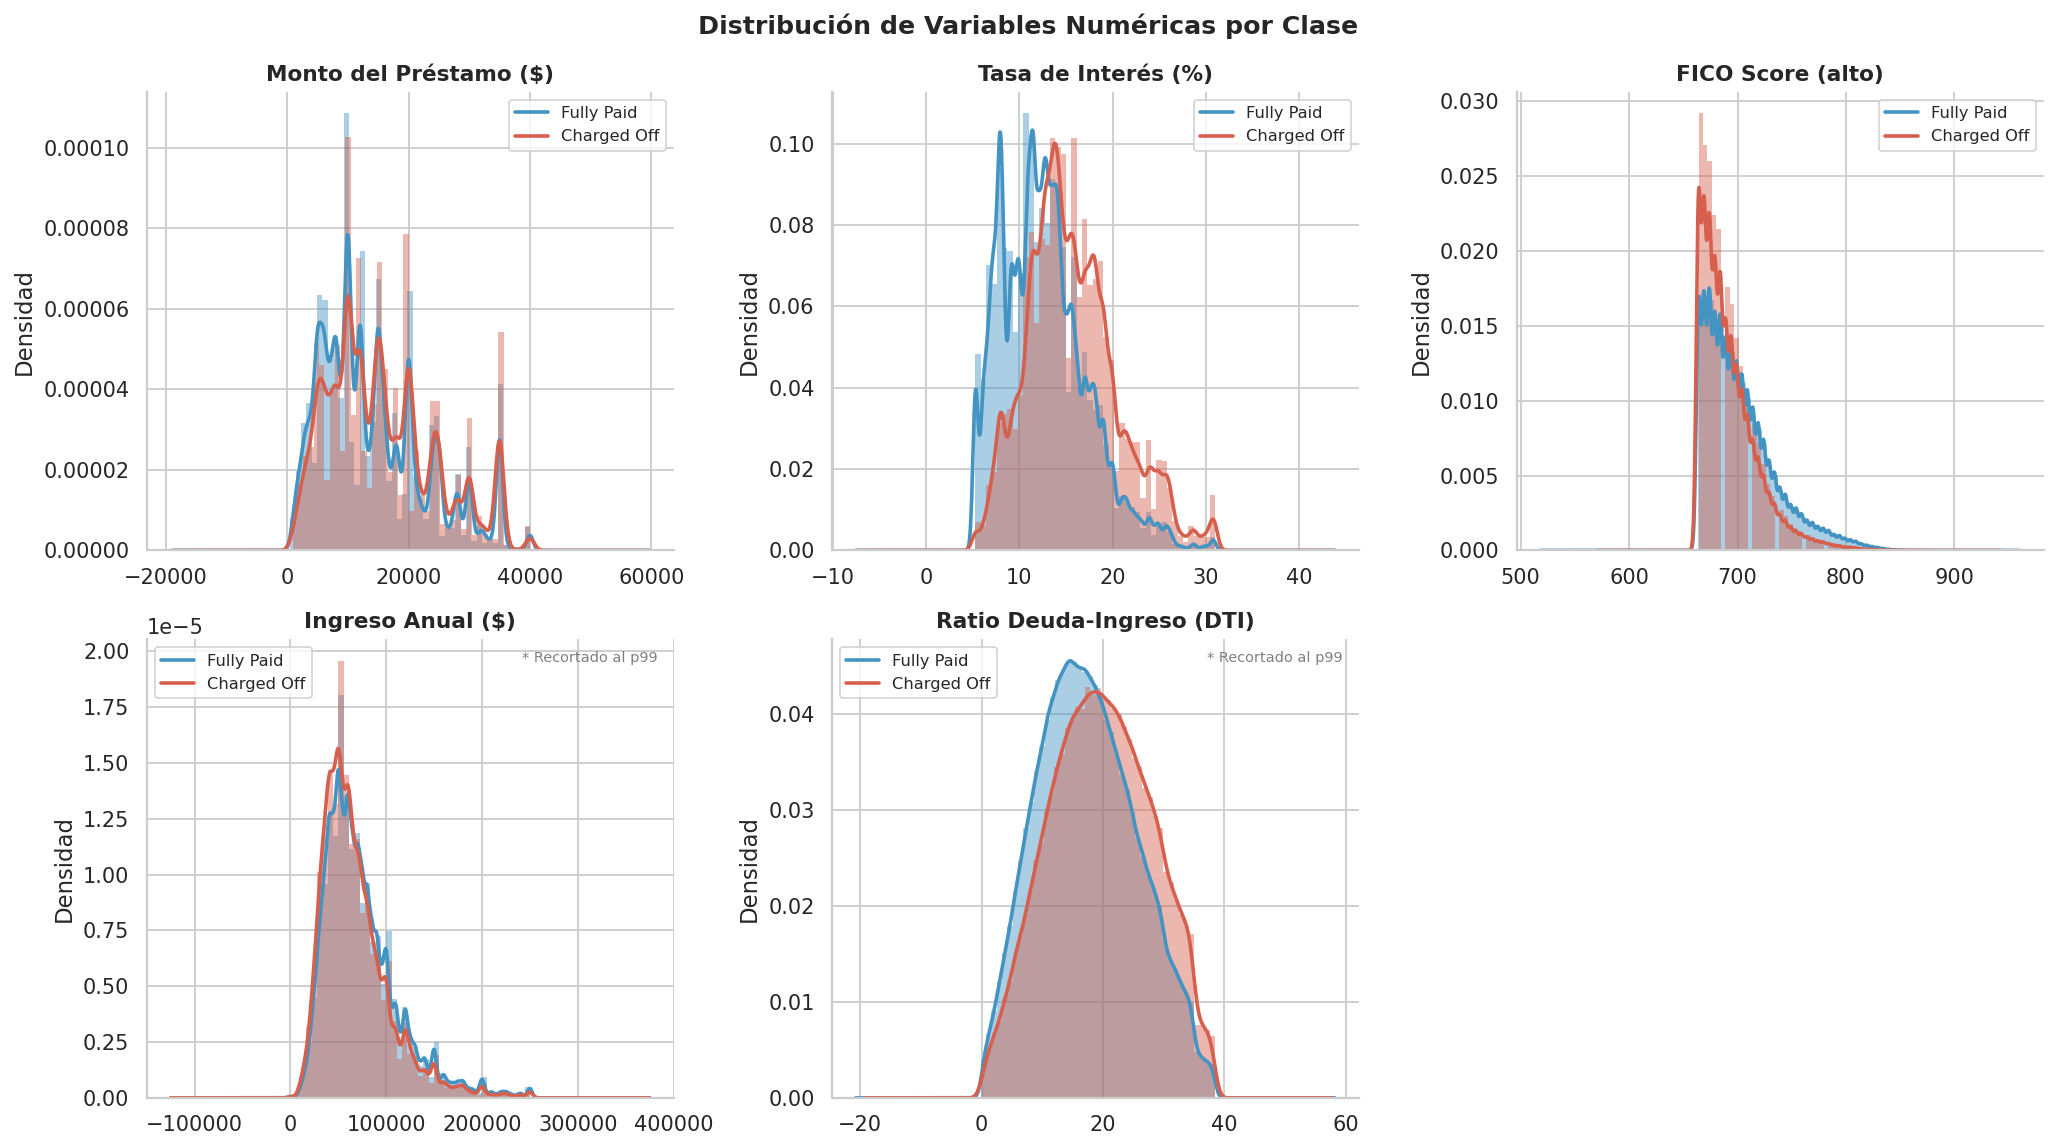

In [8]:
num_cols  = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti']
col_names = {
    'loan_amnt'       : 'Monto del Préstamo ($)',
    'int_rate'        : 'Tasa de Interés (%)',
    'fico_range_high' : 'FICO Score (alto)',
    'annual_inc'      : 'Ingreso Anual ($)',
    'dti'             : 'Ratio Deuda-Ingreso (DTI)'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribución de Variables Numéricas por Clase', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

# Límites de percentil para recortar outliers extremos en la visualización
clip_p = {'annual_inc': 99, 'loan_amnt': 100, 'int_rate': 100,
          'fico_range_high': 100, 'dti': 99}

for i, col in enumerate(num_cols):
    ax = axes_flat[i]
    pct = clip_p.get(col, 100)
    clip_val = df_subset[col].quantile(pct / 100)
    data_clipped = df_subset[df_subset[col] <= clip_val]

    for val, label, color in zip([0, 1], ['Fully Paid', 'Charged Off'], PALETTE_2):
        subset = data_clipped[data_clipped['default'] == val][col].dropna()
        ax.hist(subset, bins=45, alpha=0.45, color=color, density=True, edgecolor='none')
        subset.plot.kde(ax=ax, color=color, linewidth=2, label=label)

    ax.set_title(col_names[col])
    ax.set_xlabel('')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)
    if pct < 100:
        ax.annotate(f'* Recortado al p{pct}', xy=(0.97, 0.95), xycoords='axes fraction',
                    ha='right', fontsize=8, color='gray')

# Apagar el subplot sobrante
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

## **Boxplots por Clase**

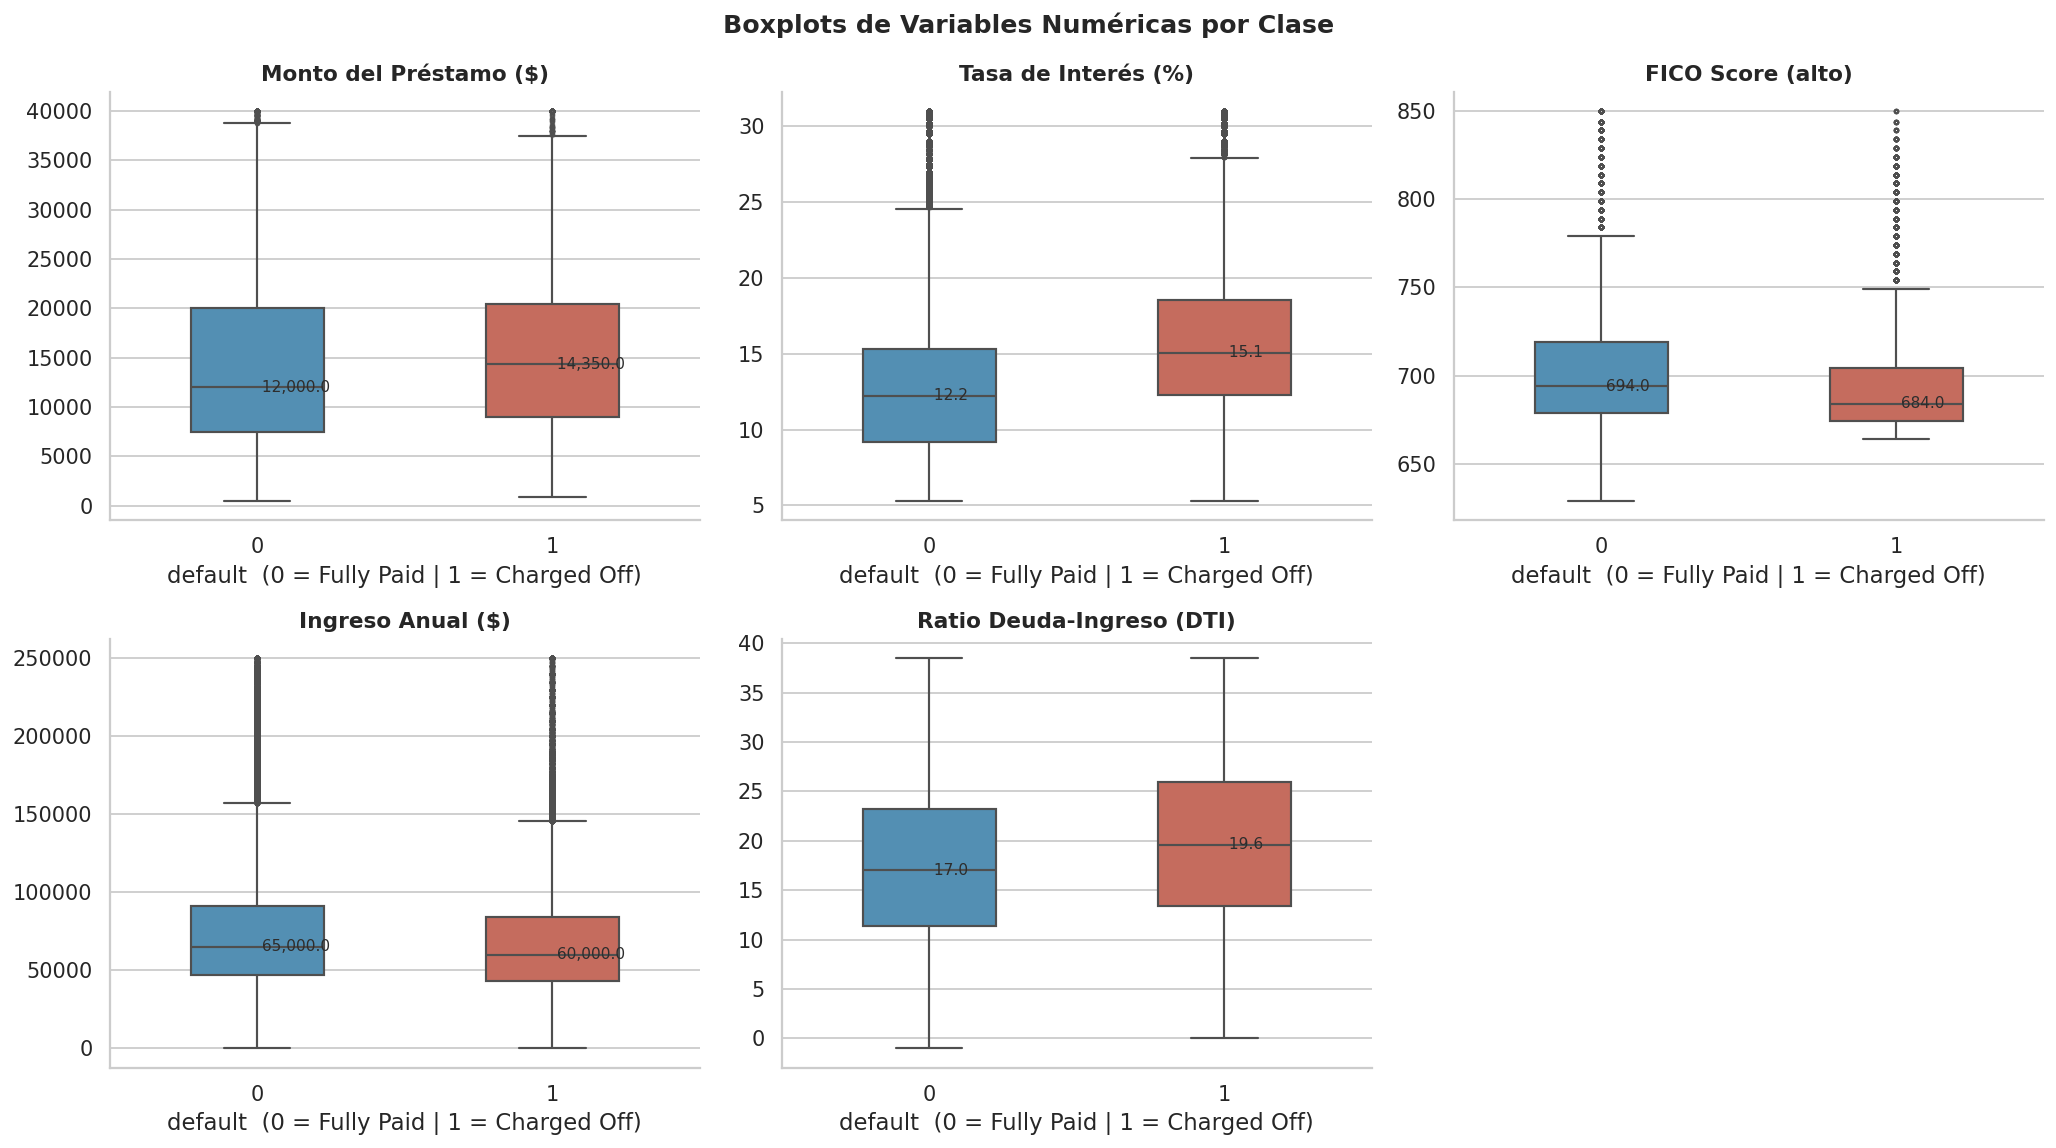

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Boxplots de Variables Numéricas por Clase', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes_flat[i]
    pct = clip_p.get(col, 100)
    clip_val = df_subset[col].quantile(pct / 100)
    data_clipped = df_subset[df_subset[col] <= clip_val][['default', col]].dropna()

    sns.boxplot(
        data=data_clipped, x='default', y=col,
        palette={'0': C_PAID, '1': C_DEFAULT},
        width=0.45, linewidth=1.2,
        flierprops=dict(marker='o', markersize=2, alpha=0.3),
        ax=ax
    )
    ax.set_title(col_names[col])
    ax.set_xlabel('default  (0 = Fully Paid | 1 = Charged Off)')
    ax.set_ylabel('')

    # Mediana anotada
    for cls in [0, 1]:
        med = data_clipped[data_clipped['default'] == cls][col].median()
        ax.text(cls, med, f' {med:,.1f}', va='center', fontsize=8.5, color='#2d2d2d')

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
num_cols = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti'] # Removed 'emp_length'

rows = []
for col in num_cols:
    Q1  = df_subset[col].quantile(0.25)
    Q3  = df_subset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df_subset[col] < lower) | (df_subset[col] > upper)).sum()
    pct        = n_outliers / df_subset[col].notna().sum() * 100
    p99        = df_subset[col].quantile(0.99)
    max_val    = df_subset[col].max()

    rows.append({
        'feature'    : col,
        'Q1'         : Q1,
        'Q3'         : Q3,
        'IQR'        : IQR,
        'lower_fence': lower,
        'upper_fence': upper,
        'max'        : max_val,
        'p99'        : p99,
        'n_outliers' : n_outliers,
        'pct_outliers': round(pct, 2)
    })

outlier_df = pd.DataFrame(rows).set_index('feature')
print('── Análisis de Outliers (criterio IQR) ──\n')
print(outlier_df.round(2).to_string())

── Análisis de Outliers (criterio IQR) ──

                       Q1        Q3       IQR  lower_fence  upper_fence          max        p99  n_outliers  pct_outliers
feature                                                                                                                  
loan_amnt         8000.00  20000.00  12000.00    -10000.00     38000.00     40000.00   35000.00        7157          0.53
int_rate             9.75     15.99      6.24         0.39        25.35        30.99      26.30       24977          1.86
fico_range_high    674.00    714.00     40.00       614.00       774.00       850.00     804.00       46497          3.46
annual_inc       45780.00  90000.00  44220.00    -20550.00    156330.00  10999200.00  250000.00       65870          4.90
dti                 11.79     24.06     12.27        -6.62        42.46       999.00      38.47        5473          0.41


Haciendo un anailisis de las distribuciones de las variables numericas, las mas problematicas son **Ingreso Anual** y **DTI**, por tal motivo se realizara una transformacion logaritmica de estas variables antes del modelamiento.

| Variable         | Decisión         | Justificación                                      |
|------------------|------------------|----------------------------------------------------|
| loan_amnt        | Sin tratamiento  | Variable Acotada               |
| int_rate         | Sin tratamiento  | Variable Acotada               |
| fico_range_high  | Sin tratamiento  | 850 es el máximo teórico posible                   |
| annual_inc       | log1p            | Valores extremos reales pero muy sesgados          |
| dti              | log1p            | Valor máximo de 999        |
| emp_length       | Sin tratamiento  | Variable discreta 0–10, sin outliers               |

# **Tasa de Defaul por Categoria**

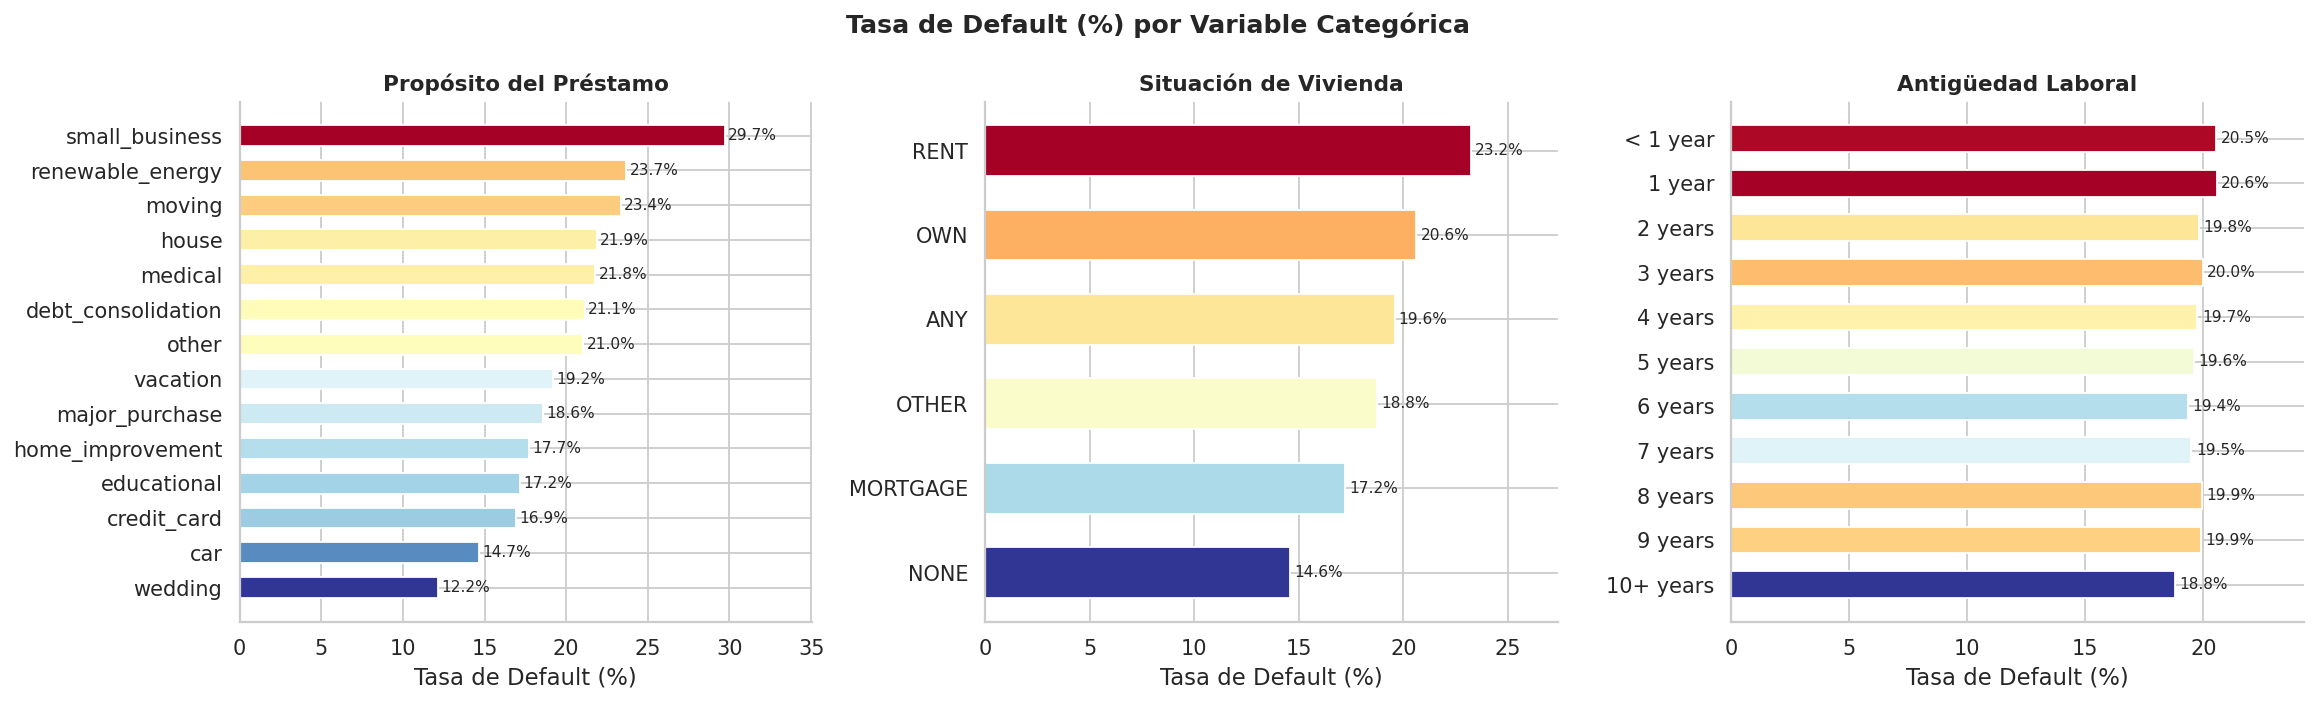

In [10]:
cat_cols = {
    'purpose'       : 'Propósito del Préstamo',
    'home_ownership': 'Situación de Vivienda',
    'emp_length'    : 'Antigüedad Laboral'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Tasa de Default (%) por Variable Categórica', fontsize=14, fontweight='bold')

# Orden de emp_length lógico
emp_order = ['< 1 year','1 year','2 years','3 years','4 years',
             '5 years','6 years','7 years','8 years','9 years','10+ years']

for ax, (col, title) in zip(axes, cat_cols.items()):
    rate = (
        df_subset.groupby(col)['default']
        .mean()
        .mul(100)
        .round(2)
        .reset_index()
        .rename(columns={'default': 'default_rate'})
    )

    if col == 'emp_length':
        rate['sort_key'] = rate[col].map({v: i for i, v in enumerate(emp_order)})
        rate = rate.dropna(subset=['sort_key']).sort_values('sort_key')
    else:
        rate = rate.sort_values('default_rate', ascending=False)

    # Colorear barras por tasa (mapa RdYlBu invertido: rojo=alto default)
    norm_vals = (rate['default_rate'] - rate['default_rate'].min()) / \
                (rate['default_rate'].max() - rate['default_rate'].min() + 1e-9)
    colors = plt.cm.RdYlBu_r(norm_vals)

    bars = ax.barh(rate[col], rate['default_rate'], color=colors, edgecolor='white', height=0.6)

    for bar, val in zip(bars, rate['default_rate']):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8.5)

    ax.set_title(title)
    ax.set_xlabel('Tasa de Default (%)')
    ax.set_xlim(0, rate['default_rate'].max() * 1.18)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

*   **Propósito**: small_business con 29.7% destaca claramente del resto. Los préstamos de negocio tienen un perfil de riesgo fundamentalmente diferente, flujo de caja incierto, dependencia de factores externos. wedding con 12.2% es el más seguro, lo cual también tiene lógica — es un gasto puntual con motivación fuerte para cumplir.
*   **Situación de vivienda**: la diferencia entre RENT (23.2%) y MORTGAGE (17.2%) es significativa y contraintuitiva a primera vista. Uno podría pensar que quien tiene hipoteca tiene más compromisos y mayor riesgo, pero tener hipoteca aprobada podria ser una señal de solvencia crediticia previa. NONE con 14.6% es interesante, probablemente personas que viven con familiares sin gastos de vivienda fija.
* **Antigüedad laboral**: aquí la gráfica es casi plana. Esto sugiere que emp_length probablemente tiene poco poder predictivo individual.


## **Tasa de Default por Estado**

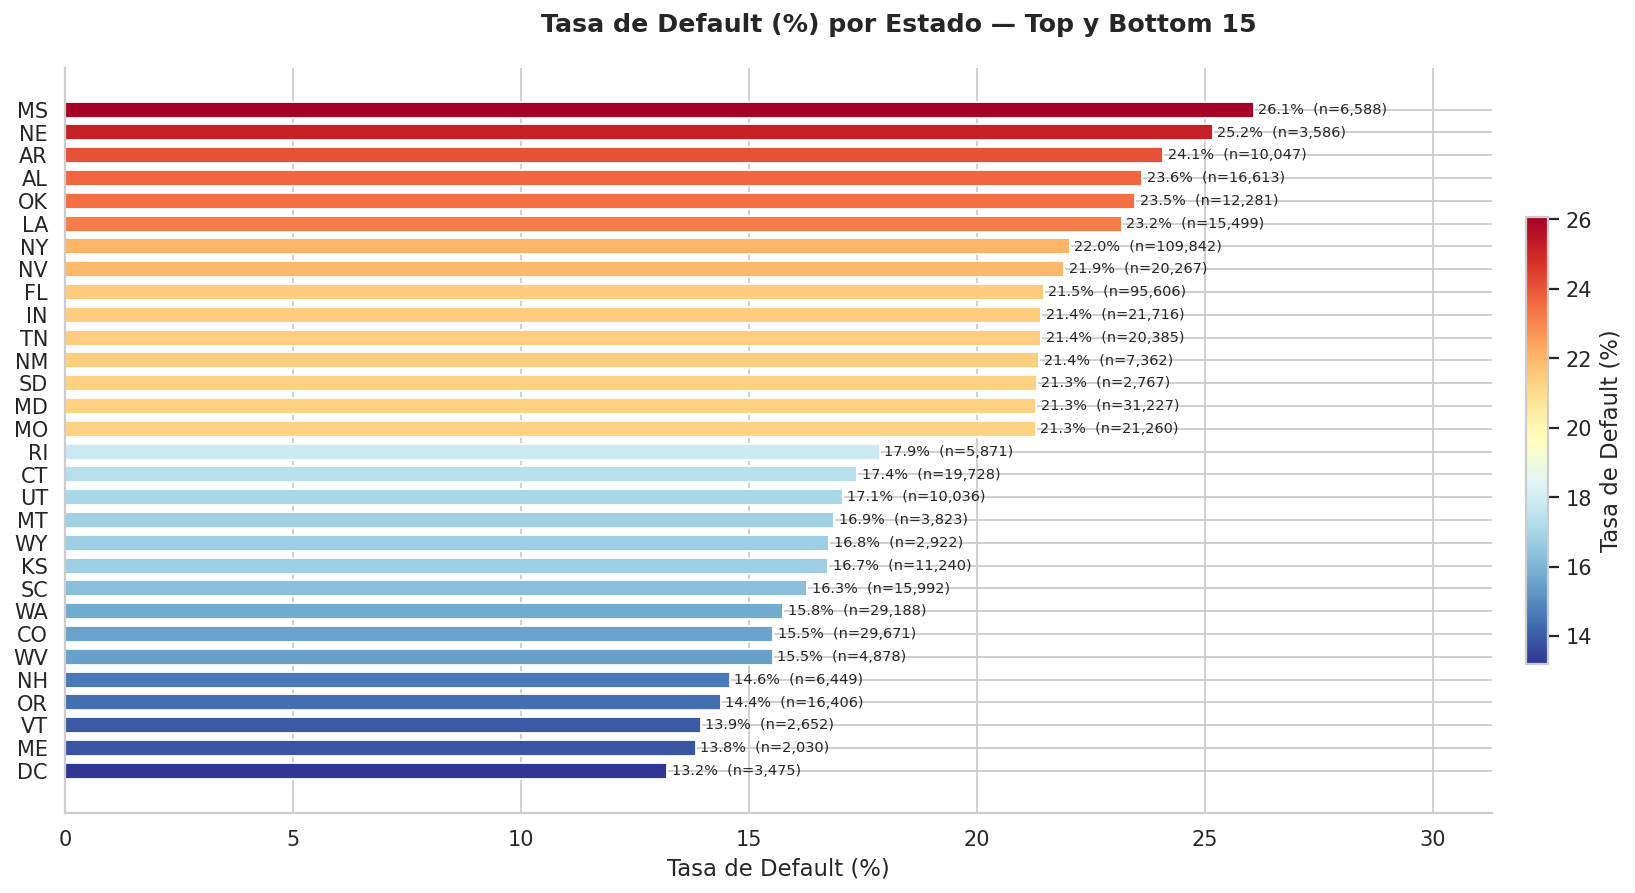

In [11]:
state_rate = (
    df_subset.groupby('addr_state')['default']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'default_rate', 'count': 'n_loans'})
    .reset_index()
)
state_rate['default_rate'] = (state_rate['default_rate'] * 100).round(2)

# Filtrar estados con al menos 500 préstamos para evitar ruido
state_rate = state_rate[state_rate['n_loans'] >= 500].sort_values('default_rate', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('Tasa de Default (%) por Estado — Top y Bottom 15', fontsize=14, fontweight='bold')

top15    = state_rate.head(15)
bottom15 = state_rate.tail(15)
combined = pd.concat([top15, bottom15]).drop_duplicates()

norm_vals = (combined['default_rate'] - combined['default_rate'].min()) / \
            (combined['default_rate'].max() - combined['default_rate'].min() + 1e-9)
colors = plt.cm.RdYlBu_r(norm_vals)

bars = ax.barh(combined['addr_state'], combined['default_rate'],
               color=colors, edgecolor='white', height=0.7)

for bar, row in zip(bars, combined.itertuples()):
    ax.text(row.default_rate + 0.1, bar.get_y() + bar.get_height()/2,
            f'{row.default_rate:.1f}%  (n={row.n_loans:,})',
            va='center', fontsize=8)

ax.set_xlabel('Tasa de Default (%)')
ax.set_xlim(0, combined['default_rate'].max() * 1.2)
ax.invert_yaxis()

# Colorbar de referencia
sm = plt.cm.ScalarMappable(cmap='RdYlBu_r',
                            norm=plt.Normalize(combined['default_rate'].min(),
                                               combined['default_rate'].max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Tasa de Default (%)', shrink=0.6, pad=0.02)

plt.tight_layout()
plt.show()

Parece ser que addr_state aporta señal real y que podra ser una feature de gran importancia para el modelo.

## **Matriz de Correlacion**

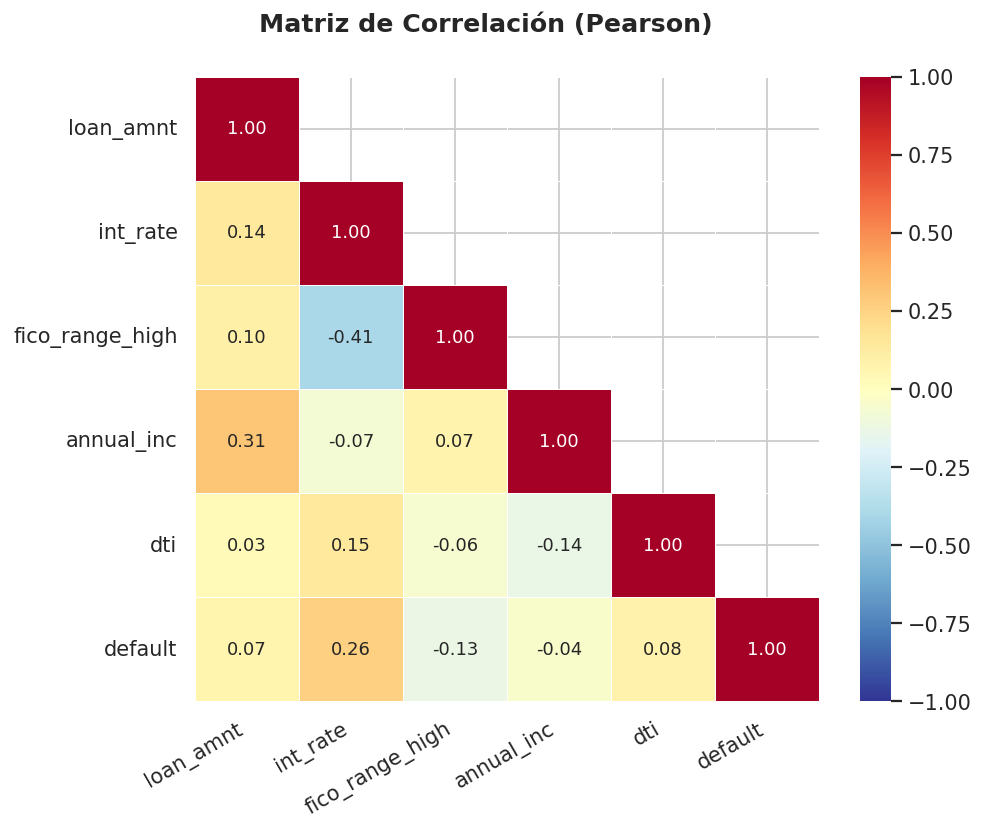


── Correlación con la variable target (default) ──
int_rate           0.2588
fico_range_high   -0.1307
dti                0.0845
loan_amnt          0.0656
annual_inc        -0.0418


In [12]:
# Solo variables numéricas + target
corr_cols = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti', 'default']
corr_df   = df_subset[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
fig.suptitle('Matriz de Correlación (Pearson)', fontsize=14, fontweight='bold')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # triángulo superior

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    annot_kws={'size': 10},
    ax=ax
)

# Resaltar columna/fila de 'default'
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print('\n── Correlación con la variable target (default) ──')
print(corr_matrix['default'].drop('default').sort_values(key=abs, ascending=False).round(4).to_string())

Tres cosas llaman la atención:
*   int_rate con 0.26 de correlación con default es la variable numérica más predictiva, lo cual es intuitivo — tasas altas reflejan que Lending Club ya percibía mayor riesgo en ese préstamo al momento de emitirlo.
*   fico_range_high con -0.41 con int_rate es la correlación más fuerte del dataset. No es sorprendente — a mejor score crediticio, menor tasa asignada. Pero esto sugiere multicolinealidad moderada entre dos de nuestras features.
* Lo preocupante: annual_inc y dti tienen correlaciones casi nulas con default (−0.04 y 0.08). Eso no significa que no sean útiles — Random Forest captura interacciones no lineales.

## **Analisis de Datos Faltantes**

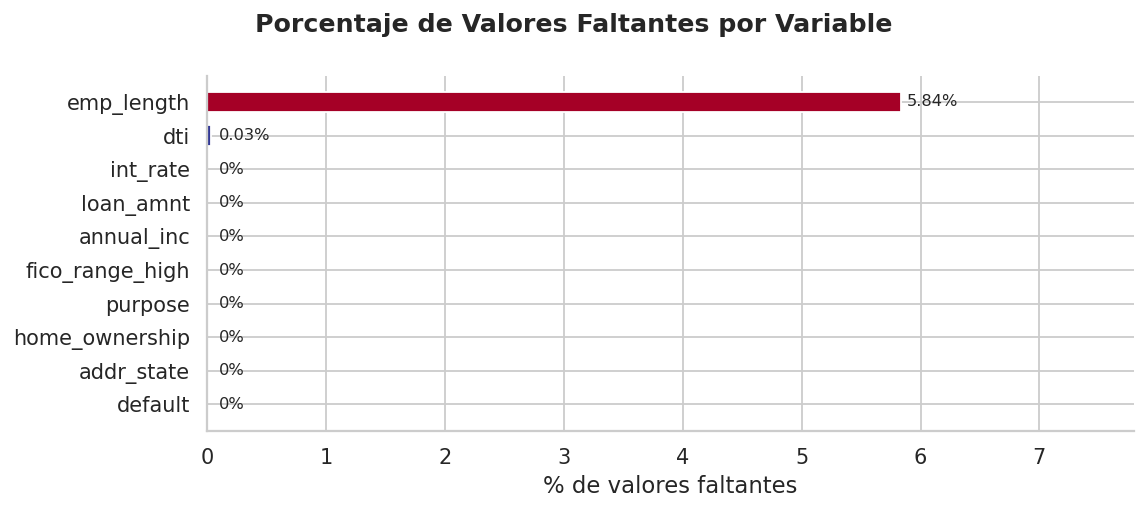


Resumen:
        feature  missing_pct
     emp_length     5.835904
            dti     0.027800
       int_rate     0.000000
      loan_amnt     0.000000
     annual_inc     0.000000
fico_range_high     0.000000
        purpose     0.000000
 home_ownership     0.000000
     addr_state     0.000000
        default     0.000000


In [13]:
miss_pct = (df_subset.isnull().sum() / len(df_subset) * 100).sort_values(ascending=False)
miss_df   = miss_pct.reset_index()
miss_df.columns = ['feature', 'missing_pct']

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('Porcentaje de Valores Faltantes por Variable', fontsize=14, fontweight='bold')

norm_miss = miss_df['missing_pct'] / (miss_df['missing_pct'].max() + 1e-9)
colors    = plt.cm.RdYlBu_r(norm_miss)

bars = ax.barh(miss_df['feature'], miss_df['missing_pct'],
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, miss_df['missing_pct']):
    label = f'{val:.2f}%' if val > 0 else '0%'
    ax.text(max(val + 0.05, 0.1), bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9)

ax.set_xlabel('% de valores faltantes')
ax.set_xlim(0, miss_df['missing_pct'].max() * 1.25 + 0.5)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print('\nResumen:')
print(miss_df.to_string(index=False))

Solo dos features presentan valores faltantes y se decidio hacer imputacion mediante la mediana.

# **Preprocesamiento**

## **Limpieza**

La variable `emp_length` viene como string (`"10+ years"`, `"< 1 year"`, etc.).
Se extrae el valor numérico y se imputan los NaN con la **mediana**.

In [14]:
import re

def parse_emp_length(val):
    """Convierte emp_length string a entero.
    '< 1 year' -> 0  |  '10+ years' -> 10  |  '5 years' -> 5
    """
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.startswith('<'):
        return 0
    match = re.search(r'(\d+)', val)
    return int(match.group(1)) if match else np.nan

df_parsed = df_subset.copy()
df_parsed['emp_length'] = df_parsed['emp_length'].apply(parse_emp_length)

# **Dataset to .parquet**
Con el objetivo de obtener un mejor rendimiento a la hora de hacer el modelado y optimizar los escazoz recursos con los que se cuenta se ha decidido convertir el set de datos de .csv a .parquet

In [ ]:
PATH = '/content/drive/MyDrive/Datasets/Miniproyecto 1/df_parsed.parquet'

df_parsed.to_parquet(PATH, index=False)

In [ ]:
PATH = '/kaggle/input/datasets/luiscabarcas/loan-accepted'
df_parsed = pd.read_parquet(PATH)

### **Split — Train / Test (80/20)**

In [ ]:
from sklearn.model_selection import train_test_split

NUM_FEATURES = ['loan_amnt', 'int_rate', 'fico_range_high', 'annual_inc', 'dti', 'emp_length']
CAT_FEATURES = ['purpose', 'home_ownership', 'addr_state']
TARGET       = 'default'

X = df_parsed[NUM_FEATURES + CAT_FEATURES]
y = df_parsed[TARGET]

# Split estratificado 80/20
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

total = X.shape[0]
print(f'Total  : {total:>10,}  (100.0%)')
print(f'Train  : {X_train_raw.shape[0]:>10,}  ({X_train_raw.shape[0]/total*100:.1f}%)')
print(f'Test   : {X_test_raw.shape[0]:>10,}  ({X_test_raw.shape[0]/total*100:.1f}%)')
print(f'\nProporción default - Train: {y_train.mean()*100:.2f}%  Test: {y_test.mean()*100:.2f}%')

Total  :  1,345,310  (100.0%)
Train  :  1,076,248  (80.0%)
Test   :    269,062  (20.0%)

Proporción default - Train: 19.96%  Test: 19.96%


In [ ]:
X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

# Transformación log1p sobre annual_inc y dti
# — fit implícito en train, misma transformación aplicada a test
log_cols = ['annual_inc', 'dti']

for col in log_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])

# Reemplazar -inf/inf que pueda generar log1p sobre valores <= 0
for df_set in [X_train, X_test]:
    df_set['dti'] = df_set['dti'].replace([-np.inf, np.inf], np.nan)

# Imputación con medianas calculadas exclusivamente en train
emp_median_train = X_train['emp_length'].median()
dti_median_train = X_train['dti'].median()

X_train['emp_length'] = X_train['emp_length'].fillna(emp_median_train)
X_test['emp_length']  = X_test['emp_length'].fillna(emp_median_train)

X_train['dti'] = X_train['dti'].fillna(dti_median_train)
X_test['dti']  = X_test['dti'].fillna(dti_median_train)

## **Preprocesamiento — scikit-learn**

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose        import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),
                              NUM_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                              CAT_FEATURES)
    ],
    remainder='passthrough'
)

# fit SOLO sobre train — transform sobre train y test
X_train_sk = preprocessor.fit_transform(X_train)
X_test_sk  = preprocessor.transform(X_test)

# Nombres de features resultantes
ohe_feature_names = preprocessor.named_transformers_['cat'] \
                    .get_feature_names_out(CAT_FEATURES).tolist()
all_feature_names = NUM_FEATURES + ohe_feature_names

print(f'Dimensiones X_train_sk : {X_train_sk.shape}')
print(f'Dimensiones X_test_sk  : {X_test_sk.shape}')
print(f'Total features         : {len(all_feature_names)}')
print(f'  Numéricas            : {len(NUM_FEATURES)}')
print(f'  One-Hot              : {len(ohe_feature_names)}')

Dimensiones X_train_sk : (1076248, 77)
Dimensiones X_test_sk  : (269062, 77)
Total features         : 77
  Numéricas            : 6
  One-Hot              : 71
